# [15.1] LoRA, DoRA, and Adapter Controls

By the end of this notebook, you will have shown that a PEFT adapter on a safe planted-direction proxy is only credible when it improves held-out behavior and the learned update/activation drift points at the planted mechanism while matched controls fail.

## Core Question

When a small adapter changes a frozen model, what evidence tells you whether it learned the intended mechanism rather than a cheap side effect?

**Common bug:** treating high held-out accuracy or one dominant singular value as a mechanism result. The claim also requires merge parity, target-direction alignment, protected-direction checks, OOD behavior, and matched random-label and same-norm controls.

The learning object is not a JSON report. You will build the LoRA and DoRA math directly, train matched adapters on a generated task with known ground truth, and make the signature panel yourself: training curves, singular values, behavior bars, direction drift, activation-margin drift, merge parity, and example-level OOD predictions.

This is a safe proxy. The labels are generated from feature 0 of Gaussian activation-like vectors. The frozen baseline follows feature 1, a distractor. Nothing here trains or distributes a refusal-suppression adapter or an unsafe public adapter.

## Learning Objectives

1. Compute `delta_W = (alpha / rank) * (B @ A)` and prove the rank bound on the actual update.
2. Test merged and unmerged LoRA parity on logits.
3. Recompose DoRA weights by separating row direction from row magnitude.
4. Train LoRA, DoRA, and full-finetune classifiers on the same planted-direction task.
5. Audit behavior on in-distribution and OOD distractor-conflict examples.
6. Measure weight-space and activation-margin drift toward target, distractor, and protected directions.
7. Reject random-label and same-norm random-adapter controls.
8. Use `rank`, `alpha`, `seed`, and `method` as experimental controls rather than magic constants.

![15.1 validation loop](../../instructions/assets/lora_dora_adapter_controls_validation_loop.svg)

## Cold Open

The proxy task is deliberately small enough to inspect. Inputs have eight coordinates. The true label is `1[x0 > 0]`. The frozen classifier ignores `x0` and instead follows `x1`, so it sits near chance on the training distribution and fails badly when the OOD split makes `x1` conflict with the label.

The question is whether an adapter can move the decision boundary from `x1` to `x0` without drifting into an unrelated protected coordinate `x2`. Accuracy alone is not enough: a same-norm random adapter and a random-label adapter are both real trained or real sampled objects, and both should fail visibly.

## Setup

In [1]:
import json
import math
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Literal

import matplotlib.pyplot as plt
import pandas as pd
import torch as t
from IPython.display import display
from torch import nn

chapter = "chapter15_peft_misalignment"
section = "part1_lora_dora_adapter_controls"
root_dir = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / chapter).exists())
exercises_dir = root_dir / chapter / "exercises"
section_dir = exercises_dir / section
asset_dir = root_dir / chapter / "instructions" / "assets"
asset_dir.mkdir(parents=True, exist_ok=True)

if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))
if str(exercises_dir) not in sys.path:
    sys.path.append(str(exercises_dir))

import part1_lora_dora_adapter_controls.tests as tests
from part1_lora_dora_adapter_controls import solutions as reference

GT_TIER = "GT-0"
EXERCISE_ID = "15_1_lora_dora_and_adapter_controls"
DIFFICULTY = 3
IMPORTANCE = 3
EXPECTED_RUNTIME = "seconds on toy contract; minutes on local real-model path"
REQUIRES_GPU = True

In [2]:
@dataclass(frozen=True)
class AdapterDeltaReport:
    rank: int
    alpha: float
    update_norm: float
    nonzero_update: bool


@dataclass(frozen=True)
class DoRAWeightReport:
    target_norms: t.Tensor
    row_norms: t.Tensor
    max_norm_error: float
    norm_preserved: bool


@dataclass(frozen=True)
class IntruderDimensionReport:
    projection_fraction: float
    intruder_detected: bool


@dataclass(frozen=True)
class AdapterMechanismReport:
    accuracy_delta: float
    mechanism_delta: float
    accuracy_improved: bool
    mechanism_preserved: bool
    adapter_acceptable: bool

## 1. Exact LoRA Math

Start with the piece that should never be mysterious. If `A` has shape `(rank, in_features)` and `B` has shape `(out_features, rank)`, then `B @ A` has the shape of the frozen weight. The `alpha / rank` factor is the LoRA scaling convention.

### Exercise - compute the low-rank adapter update

> Difficulty: easy  
> Importance: high  
> Time: 5 minutes

Implement the exact LoRA update and shape checks. The test includes a one-rank fixture with every number visible.

<details>
<summary>Expected output</summary>

```text
All tests in `test_lora_delta_uses_scaled_b_matrix_times_a_matrix` passed!
```

The exact fixture should produce `[[6.0, 12.0], [8.0, 16.0]]`.

</details>

<details>
<summary>Help - check the reasoning before opening the solution</summary>

The frozen weight maps `in_features` to `out_features`, so the adapter update must be `(out_features, in_features)`. That shape comes from `B @ A`, not `A @ B`.

</details>

<details>
<summary>Interpretation</summary>

This test prevents the most common LoRA bug: transposing the low-rank factors and silently auditing the wrong matrix.

</details>

<details>
<summary>Solution</summary>

```python
def lora_delta(lora_a: t.Tensor, lora_b: t.Tensor, *, alpha: float = 1.0) -> t.Tensor:
    """Return the LoRA update for A=(rank, in) and B=(out, rank)."""

    if lora_a.ndim != 2 or lora_b.ndim != 2:
        raise ValueError("lora_a and lora_b must both be matrices.")
    rank = lora_a.shape[0]
    if rank == 0:
        raise ValueError("LoRA rank must be positive.")
    if lora_b.shape[1] != rank:
        raise ValueError("lora_b second dimension must match LoRA rank.")
    return (alpha / rank) * (lora_b.float() @ lora_a.float())
```

</details>

In [3]:
def lora_delta(lora_a: t.Tensor, lora_b: t.Tensor, *, alpha: float = 1.0) -> t.Tensor:
    """Return the LoRA update for A=(rank, in) and B=(out, rank)."""

    if lora_a.ndim != 2 or lora_b.ndim != 2:
        raise ValueError("lora_a and lora_b must both be matrices.")
    rank = lora_a.shape[0]
    if rank == 0:
        raise ValueError("LoRA rank must be positive.")
    if lora_b.shape[1] != rank:
        raise ValueError("lora_b second dimension must match LoRA rank.")
    return (alpha / rank) * (lora_b.float() @ lora_a.float())

### Exercise - summarize rank, norm, and SVD spectrum

> Difficulty: medium  
> Importance: high  
> Time: 10 minutes

Build a report that records declared rank, scaling, update norm, and whether the adapter is nonzero. Then test the numerical rank on the actual update.

<details>
<summary>Expected output</summary>

```text
All tests in `test_adapter_delta_report_records_rank_alpha_and_nonzero_update` passed!
All tests in `test_lora_delta_rank_bound_and_svd_spectrum` passed!
```

</details>

<details>
<summary>Help - check the reasoning before opening the solution</summary>

`rank(B @ A) <= rank` because every update vector must pass through the rank-sized bottleneck. A degenerate adapter can have lower rank, but not higher rank.

</details>

<details>
<summary>Interpretation</summary>

The SVD is not decoration. Later, the learned LoRA spectrum is the easiest way to see whether a rank-one adapter really learned one dominant direction.

</details>

<details>
<summary>Solution</summary>

```python
def adapter_delta_report(
    lora_a: t.Tensor,
    lora_b: t.Tensor,
    *,
    alpha: float = 1.0,
    min_update_norm: float = 1e-6,
) -> AdapterDeltaReport:
    """Summarize a LoRA update before trusting an adapter artifact."""

    delta = lora_delta(lora_a, lora_b, alpha=alpha)
    update_norm = float(delta.norm().item())
    return AdapterDeltaReport(
        rank=lora_a.shape[0],
        alpha=alpha,
        update_norm=update_norm,
        nonzero_update=update_norm >= min_update_norm,
    )
```

</details>

In [4]:
def adapter_delta_report(
    lora_a: t.Tensor,
    lora_b: t.Tensor,
    *,
    alpha: float = 1.0,
    min_update_norm: float = 1e-6,
) -> AdapterDeltaReport:
    """Summarize a LoRA update before trusting an adapter artifact."""

    delta = lora_delta(lora_a, lora_b, alpha=alpha)
    update_norm = float(delta.norm().item())
    return AdapterDeltaReport(
        rank=lora_a.shape[0],
        alpha=alpha,
        update_norm=update_norm,
        nonzero_update=update_norm >= min_update_norm,
    )

### Exercise - test merge and unmerge parity

> Difficulty: medium  
> Importance: high  
> Time: 10 minutes

Compute logits through the separate adapter path and through a merged weight. They should agree to numerical precision and must not mutate the frozen base weight.

<details>
<summary>Expected output</summary>

```text
All tests in `test_lora_merge_unmerge_parity_is_independent_of_report` passed!
```

The fixture should report a max absolute logit difference below `1e-6`.

</details>

<details>
<summary>Help - check the reasoning before opening the solution</summary>

The separate path is `x @ W.T + x @ delta_W.T`. The merged path is `x @ (W + delta_W).T`. Matrix multiplication distributes over addition.

</details>

<details>
<summary>Interpretation</summary>

Merge parity is a deployment check. If this fails, every downstream behavior comparison is suspect because train-time and inference-time paths disagree.

</details>

<details>
<summary>Solution</summary>

```python
def lora_merge_max_abs_diff(
    inputs: t.Tensor,
    base_weight: t.Tensor,
    lora_a: t.Tensor,
    lora_b: t.Tensor,
    *,
    alpha: float = 1.0,
) -> float:
    """Compare unmerged adapter logits to merged-weight logits."""

    if inputs.ndim != 2 or base_weight.ndim != 2:
        raise ValueError("inputs and base_weight must be matrices.")
    delta = lora_delta(lora_a, lora_b, alpha=alpha)
    if base_weight.shape != delta.shape:
        raise ValueError("base_weight and LoRA delta must have the same shape.")
    if inputs.shape[-1] != base_weight.shape[-1]:
        raise ValueError("input dimension must match base_weight input features.")
    unmerged_logits = inputs.float() @ base_weight.float().T + inputs.float() @ delta.T
    merged_logits = inputs.float() @ (base_weight.float() + delta).T
    return float((unmerged_logits - merged_logits).abs().max().item())
```

</details>

In [5]:
def lora_merge_max_abs_diff(
    inputs: t.Tensor,
    base_weight: t.Tensor,
    lora_a: t.Tensor,
    lora_b: t.Tensor,
    *,
    alpha: float = 1.0,
) -> float:
    """Compare unmerged adapter logits to merged-weight logits."""

    if inputs.ndim != 2 or base_weight.ndim != 2:
        raise ValueError("inputs and base_weight must be matrices.")
    delta = lora_delta(lora_a, lora_b, alpha=alpha)
    if base_weight.shape != delta.shape:
        raise ValueError("base_weight and LoRA delta must have the same shape.")
    if inputs.shape[-1] != base_weight.shape[-1]:
        raise ValueError("input dimension must match base_weight input features.")
    unmerged_logits = inputs.float() @ base_weight.float().T + inputs.float() @ delta.T
    merged_logits = inputs.float() @ (base_weight.float() + delta).T
    return float((unmerged_logits - merged_logits).abs().max().item())

## 2. DoRA Direction and Magnitude

DoRA changes the audit question. The low-rank update changes the row direction, while learned magnitudes control row norms. A correct recomposition must preserve the requested row magnitudes even when the direction changes.

### Exercise - preserve learned row magnitudes

> Difficulty: medium  
> Importance: high  
> Time: 10 minutes

Normalize each updated row direction, then apply the learned row magnitude. The tests include zero-delta and nonzero-delta cases.

<details>
<summary>Expected output</summary>

```text
All tests in `test_dora_recompose_weight_preserves_target_row_magnitudes` passed!
All tests in `test_dora_recomposition_handles_nonzero_delta_direction` passed!
```

The visible zero-delta fixture returns row norms `[10.0, 5.0]`.

</details>

<details>
<summary>Help - check the reasoning before opening the solution</summary>

Normalize row-by-row with `keepdim=True`, clamp the denominator, and multiply by `magnitude[:, None]`.

</details>

<details>
<summary>Interpretation</summary>

This distinguishes DoRA from simply scaling an unnormalized LoRA-updated row, which would leak the old row norm back into the recomposed weight.

</details>

<details>
<summary>Solution</summary>

```python
def dora_recompose_weight(
    base_weight: t.Tensor,
    adapter_delta: t.Tensor,
    magnitude: t.Tensor,
    *,
    eps: float = 1e-8,
) -> t.Tensor:
    """Recompose a DoRA weight from an updated direction and row magnitudes."""

    if base_weight.shape != adapter_delta.shape:
        raise ValueError("base_weight and adapter_delta must match.")
    if magnitude.ndim != 1 or magnitude.shape[0] != base_weight.shape[0]:
        raise ValueError("magnitude must have shape (out_features,).")

    direction = base_weight.float() + adapter_delta.float()
    unit_direction = direction / direction.norm(dim=-1, keepdim=True).clamp_min(eps)
    return unit_direction * magnitude.float().unsqueeze(-1)


def dora_weight_report(
    base_weight: t.Tensor,
    adapter_delta: t.Tensor,
    magnitude: t.Tensor,
    *,
    max_allowed_norm_error: float = 1e-5,
) -> DoRAWeightReport:
    """Check whether DoRA recomposition preserved the target row norms."""

    recomposed = dora_recompose_weight(base_weight, adapter_delta, magnitude)
    row_norms = recomposed.norm(dim=-1)
    target_norms = magnitude.float()
    max_norm_error = float((row_norms - target_norms).abs().max().item())
    return DoRAWeightReport(
        target_norms=target_norms,
        row_norms=row_norms,
        max_norm_error=max_norm_error,
        norm_preserved=max_norm_error <= max_allowed_norm_error,
    )
```

</details>

In [6]:
def dora_recompose_weight(
    base_weight: t.Tensor,
    adapter_delta: t.Tensor,
    magnitude: t.Tensor,
    *,
    eps: float = 1e-8,
) -> t.Tensor:
    """Recompose a DoRA weight from an updated direction and row magnitudes."""

    if base_weight.shape != adapter_delta.shape:
        raise ValueError("base_weight and adapter_delta must match.")
    if magnitude.ndim != 1 or magnitude.shape[0] != base_weight.shape[0]:
        raise ValueError("magnitude must have shape (out_features,).")

    direction = base_weight.float() + adapter_delta.float()
    unit_direction = direction / direction.norm(dim=-1, keepdim=True).clamp_min(eps)
    return unit_direction * magnitude.float().unsqueeze(-1)


def dora_weight_report(
    base_weight: t.Tensor,
    adapter_delta: t.Tensor,
    magnitude: t.Tensor,
    *,
    max_allowed_norm_error: float = 1e-5,
) -> DoRAWeightReport:
    """Check whether DoRA recomposition preserved the target row norms."""

    recomposed = dora_recompose_weight(base_weight, adapter_delta, magnitude)
    row_norms = recomposed.norm(dim=-1)
    target_norms = magnitude.float()
    max_norm_error = float((row_norms - target_norms).abs().max().item())
    return DoRAWeightReport(
        target_norms=target_norms,
        row_norms=row_norms,
        max_norm_error=max_norm_error,
        norm_preserved=max_norm_error <= max_allowed_norm_error,
    )

## 3. Mechanism Gates Before Training

Before we train anything, define the safety valves. A PEFT audit should be able to say: the adapter moved along a monitored direction, or the adapter improved task accuracy while damaging the measured mechanism.

### Exercise - measure protected-direction projection and paired mechanism gates

> Difficulty: medium  
> Importance: high  
> Time: 10 minutes

Implement two reports: one for projection onto a monitored direction, and one that requires both task improvement and mechanism preservation.

<details>
<summary>Expected output</summary>

```text
All tests in `test_intruder_dimension_report_measures_projection_fraction` passed!
All tests in `test_adapter_mechanism_report_requires_accuracy_and_mechanism` passed!
```

</details>

<details>
<summary>Help - check the reasoning before opening the solution</summary>

Use projection norm, not signed projection. A large negative movement along a monitored axis is still a large movement along that axis.

</details>

<details>
<summary>Interpretation</summary>

The paired gate makes the acceptance criterion explicit: behavior and mechanism evidence are both required.

</details>

<details>
<summary>Solution</summary>

```python
def intruder_dimension_report(
    adapter_delta: t.Tensor,
    protected_direction: t.Tensor,
    *,
    max_projection_fraction: float = 0.2,
) -> IntruderDimensionReport:
    """Measure how much of an adapter update lies in a monitored direction."""

    if adapter_delta.ndim != 2:
        raise ValueError("adapter_delta must have shape (out_features, in_features).")
    if protected_direction.ndim != 1:
        raise ValueError("protected_direction must have shape (in_features,).")
    if adapter_delta.shape[-1] != protected_direction.shape[0]:
        raise ValueError("adapter and protected direction dimensions must match.")

    direction = protected_direction.float()
    direction = direction / direction.norm().clamp_min(1e-8)
    projected = adapter_delta.float() @ direction
    adapter_norm = float(adapter_delta.float().norm().clamp_min(1e-8).item())
    projection_fraction = float(projected.norm().item() / adapter_norm)
    return IntruderDimensionReport(
        projection_fraction=projection_fraction,
        intruder_detected=projection_fraction > max_projection_fraction,
    )


def adapter_mechanism_report(
    *,
    adapter_accuracy: float,
    baseline_accuracy: float,
    adapter_mechanism_score: float,
    baseline_mechanism_score: float,
    min_accuracy_gain: float = 0.05,
    min_mechanism_delta: float = -0.02,
) -> AdapterMechanismReport:
    """Require both task improvement and preservation of the measured mechanism."""

    accuracy_delta = adapter_accuracy - baseline_accuracy
    mechanism_delta = adapter_mechanism_score - baseline_mechanism_score
    accuracy_improved = accuracy_delta >= min_accuracy_gain
    mechanism_preserved = mechanism_delta >= min_mechanism_delta
    return AdapterMechanismReport(
        accuracy_delta=accuracy_delta,
        mechanism_delta=mechanism_delta,
        accuracy_improved=accuracy_improved,
        mechanism_preserved=mechanism_preserved,
        adapter_acceptable=accuracy_improved and mechanism_preserved,
    )
```

</details>

In [7]:
def intruder_dimension_report(
    adapter_delta: t.Tensor,
    protected_direction: t.Tensor,
    *,
    max_projection_fraction: float = 0.2,
) -> IntruderDimensionReport:
    """Measure how much of an adapter update lies in a monitored direction."""

    if adapter_delta.ndim != 2:
        raise ValueError("adapter_delta must have shape (out_features, in_features).")
    if protected_direction.ndim != 1:
        raise ValueError("protected_direction must have shape (in_features,).")
    if adapter_delta.shape[-1] != protected_direction.shape[0]:
        raise ValueError("adapter and protected direction dimensions must match.")

    direction = protected_direction.float()
    direction = direction / direction.norm().clamp_min(1e-8)
    projected = adapter_delta.float() @ direction
    adapter_norm = float(adapter_delta.float().norm().clamp_min(1e-8).item())
    projection_fraction = float(projected.norm().item() / adapter_norm)
    return IntruderDimensionReport(
        projection_fraction=projection_fraction,
        intruder_detected=projection_fraction > max_projection_fraction,
    )


def adapter_mechanism_report(
    *,
    adapter_accuracy: float,
    baseline_accuracy: float,
    adapter_mechanism_score: float,
    baseline_mechanism_score: float,
    min_accuracy_gain: float = 0.05,
    min_mechanism_delta: float = -0.02,
) -> AdapterMechanismReport:
    """Require both task improvement and preservation of the measured mechanism."""

    accuracy_delta = adapter_accuracy - baseline_accuracy
    mechanism_delta = adapter_mechanism_score - baseline_mechanism_score
    accuracy_improved = accuracy_delta >= min_accuracy_gain
    mechanism_preserved = mechanism_delta >= min_mechanism_delta
    return AdapterMechanismReport(
        accuracy_delta=accuracy_delta,
        mechanism_delta=mechanism_delta,
        accuracy_improved=accuracy_improved,
        mechanism_preserved=mechanism_preserved,
        adapter_acceptable=accuracy_improved and mechanism_preserved,
    )

## 4. The Safe Proxy Task

Now make the adapter itself the object of study. The task uses generated activation-like vectors with known ground truth:

- target mechanism: feature `x0` determines the label;
- frozen distractor baseline: feature `x1` determines the base prediction;
- protected direction: feature `x2` should not explain the learned margin drift;
- OOD split: `x1` is forced to conflict with the label.

In [8]:
class ProxyLoRAClassifier(nn.Module):
    """Frozen distractor classifier plus a trainable LoRA adapter."""

    def __init__(self, input_dim: int = 8, rank: int = 1, alpha: float = 4.0):
        super().__init__()
        if rank <= 0:
            raise ValueError("rank must be positive.")
        base_weight = t.zeros(2, input_dim)
        base_weight[0, 1] = 1.0
        base_weight[1, 1] = -1.0
        self.register_buffer("base_weight", base_weight)
        self.register_buffer("base_bias", t.zeros(2))
        self.lora_a = nn.Parameter(0.02 * t.randn(rank, input_dim))
        self.lora_b = nn.Parameter(t.zeros(2, rank))
        self.alpha = float(alpha)

    def delta_weight(self) -> t.Tensor:
        return lora_delta(self.lora_a, self.lora_b, alpha=self.alpha)

    def merged_weight(self) -> t.Tensor:
        return self.base_weight + self.delta_weight()

    def forward(self, inputs: t.Tensor) -> t.Tensor:
        return inputs @ self.merged_weight().T + self.base_bias


class ProxyDoRAClassifier(nn.Module):
    """Frozen distractor classifier plus a trainable DoRA adapter."""

    def __init__(self, input_dim: int = 8, rank: int = 1, alpha: float = 4.0):
        super().__init__()
        if rank <= 0:
            raise ValueError("rank must be positive.")
        base_weight = t.zeros(2, input_dim)
        base_weight[0, 1] = 1.0
        base_weight[1, 1] = -1.0
        self.register_buffer("base_weight", base_weight)
        self.register_buffer("base_bias", t.zeros(2))
        self.lora_a = nn.Parameter(0.02 * t.randn(rank, input_dim))
        self.lora_b = nn.Parameter(t.zeros(2, rank))
        self.log_magnitude = nn.Parameter(base_weight.norm(dim=-1).clamp_min(1e-6).log())
        self.alpha = float(alpha)

    def delta_weight(self) -> t.Tensor:
        return lora_delta(self.lora_a, self.lora_b, alpha=self.alpha)

    def magnitude(self) -> t.Tensor:
        return self.log_magnitude.exp()

    def recomposed_weight(self) -> t.Tensor:
        return dora_recompose_weight(self.base_weight, self.delta_weight(), self.magnitude())

    def merged_weight(self) -> t.Tensor:
        return self.recomposed_weight()

    def forward(self, inputs: t.Tensor) -> t.Tensor:
        return inputs @ self.recomposed_weight().T + self.base_bias


class ProxyFullFinetuneClassifier(nn.Module):
    """Full linear finetune initialized from the same distractor baseline."""

    def __init__(self, input_dim: int = 8):
        super().__init__()
        base_weight = t.zeros(2, input_dim)
        base_weight[0, 1] = 1.0
        base_weight[1, 1] = -1.0
        self.register_buffer("base_weight", base_weight)
        self.register_buffer("base_bias", t.zeros(2))
        self.weight = nn.Parameter(base_weight.clone())
        self.bias = nn.Parameter(t.zeros(2))

    def delta_weight(self) -> t.Tensor:
        return self.weight - self.base_weight

    def merged_weight(self) -> t.Tensor:
        return self.weight

    def forward(self, inputs: t.Tensor) -> t.Tensor:
        return inputs @ self.weight.T + self.bias

### Exercise - generate planted target and OOD conflict batches

> Difficulty: medium  
> Importance: high  
> Time: 10 minutes

Generate batches where labels are exactly `1[x0 > 0]`. The OOD option should make the frozen `x1` distractor confidently wrong without changing the true target rule.

<details>
<summary>Expected output</summary>

```text
All tests in `test_proxy_batch_has_planted_target_and_ood_conflict` passed!
```

</details>

<details>
<summary>Help - check the reasoning before opening the solution</summary>

Compute labels from `x0` first. For OOD conflict, set `x1` to have the sign that makes the frozen baseline predict the opposite class.

</details>

<details>
<summary>Interpretation</summary>

This gives you a toy ground truth before any real-model claim. You know what the adapter should learn and what the baseline should fail.

</details>

<details>
<summary>Solution</summary>

```python
def make_proxy_batch(
    *,
    batch: int,
    seed: int,
    device: t.device | str | None = None,
    random_labels: bool = False,
    ood_shift: float = 0.0,
    protected_shift: float = 0.0,
) -> tuple[t.Tensor, t.Tensor]:
    """Generate the safe planted-direction task used in the learner notebook."""

    if batch <= 0:
        raise ValueError("batch must be positive.")
    device = t.device("cpu") if device is None else t.device(device)
    generator = t.Generator(device=device).manual_seed(seed)
    inputs = t.randn(batch, 8, device=device, generator=generator)
    labels = (inputs[:, 0] > 0).long()
    if random_labels:
        labels = t.randint(0, 2, labels.shape, device=device, generator=generator)
    if ood_shift:
        signed_label = labels.float().mul(2).sub(1)
        inputs[:, 1] = float(ood_shift) * signed_label
    if protected_shift:
        protected_sign = t.randint(0, 2, labels.shape, device=device, generator=generator)
        inputs[:, 2] = float(protected_shift) * protected_sign.float().mul(2).sub(1)
    return inputs, labels
```

</details>

In [9]:
def make_proxy_batch(
    *,
    batch: int,
    seed: int,
    device: t.device | str | None = None,
    random_labels: bool = False,
    ood_shift: float = 0.0,
    protected_shift: float = 0.0,
) -> tuple[t.Tensor, t.Tensor]:
    """Generate the safe planted-direction task used in the learner notebook."""

    if batch <= 0:
        raise ValueError("batch must be positive.")
    device = t.device("cpu") if device is None else t.device(device)
    generator = t.Generator(device=device).manual_seed(seed)
    inputs = t.randn(batch, 8, device=device, generator=generator)
    labels = (inputs[:, 0] > 0).long()
    if random_labels:
        labels = t.randint(0, 2, labels.shape, device=device, generator=generator)
    if ood_shift:
        signed_label = labels.float().mul(2).sub(1)
        inputs[:, 1] = float(ood_shift) * signed_label
    if protected_shift:
        protected_sign = t.randint(0, 2, labels.shape, device=device, generator=generator)
        inputs[:, 2] = float(protected_shift) * protected_sign.float().mul(2).sub(1)
    return inputs, labels

### Exercise - train and evaluate a real adapter

> Difficulty: hard  
> Importance: high  
> Time: 20 minutes

Implement the training loop and evaluation report. Record a trace, evaluate held-out accuracy, OOD accuracy, singular values, direction cosines, and activation-margin correlations.

<details>
<summary>Expected output</summary>

```text
All tests in `test_train_proxy_adapter_returns_learning_trace_on_cpu` passed!
```

A good LoRA run should reach at least `0.95` held-out accuracy while the frozen baseline remains near chance.

</details>

<details>
<summary>Help - check the reasoning before opening the solution</summary>

For activation drift, compare the adapter margin change `(logit_1 - logit_0) - base_margin` against each input coordinate by correlation. The target coordinate should explain the margin change.

</details>

<details>
<summary>Interpretation</summary>

This is the central ARENA move in the notebook: after implementing the adapter, you inspect what it learned rather than just accepting the final loss.

</details>

<details>
<summary>Solution</summary>

```python
def proxy_trainable_parameter_count(model: nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


def _unit_basis(width: int, index: int, *, device: t.device) -> t.Tensor:
    direction = t.zeros(width, device=device)
    direction[index] = 1.0
    return direction


def _decision_direction(weight: t.Tensor) -> t.Tensor:
    if weight.ndim != 2 or weight.shape[0] != 2:
        raise ValueError("proxy classifier weight must have shape (2, input_dim).")
    return weight[1] - weight[0]


def _cosine_with_basis(vector: t.Tensor, index: int) -> float:
    basis = _unit_basis(vector.shape[0], index, device=vector.device)
    return float(nn.functional.cosine_similarity(vector.float(), basis, dim=0).item())


def _model_weight_for_proxy(model: nn.Module) -> t.Tensor:
    if hasattr(model, "recomposed_weight"):
        return model.recomposed_weight()
    if hasattr(model, "merged_weight"):
        return model.merged_weight()
    raise TypeError(f"unsupported proxy model type: {type(model)!r}")


def singular_value_spectrum(model: nn.Module) -> list[float]:
    """Return singular values of the learned adapter/update matrix."""

    weight = _model_weight_for_proxy(model)
    delta = weight - model.base_weight
    return [float(value) for value in t.linalg.svdvals(delta.float()).detach().cpu()]


def _margin_feature_correlation(
    delta_margin: t.Tensor,
    inputs: t.Tensor,
    feature: int,
) -> float:
    centered_margin = delta_margin.float() - delta_margin.float().mean()
    centered_feature = inputs[:, feature].float() - inputs[:, feature].float().mean()
    denom = centered_margin.norm() * centered_feature.norm()
    if float(denom.item()) <= 1e-8:
        return 0.0
    return float((centered_margin @ centered_feature / denom).item())


def evaluate_proxy_adapter(
    model: nn.Module,
    *,
    seed: int = 12345,
    batch: int = 2048,
    ood_shift: float = 0.0,
    protected_shift: float = 0.0,
) -> dict[str, Any]:
    """Evaluate behavior, weight direction, and activation-space drift."""

    device = next(model.parameters()).device
    inputs, labels = make_proxy_batch(
        batch=batch,
        seed=seed,
        device=device,
        ood_shift=ood_shift,
        protected_shift=protected_shift,
    )
    with t.inference_mode():
        logits = model(inputs)
        base_logits = inputs @ model.base_weight.T + model.base_bias
    predictions = logits.argmax(dim=-1)
    base_predictions = base_logits.argmax(dim=-1)
    accuracy = float(predictions.eq(labels).float().mean().item())
    baseline_accuracy = float(base_predictions.eq(labels).float().mean().item())
    weight = _model_weight_for_proxy(model)
    delta = weight - model.base_weight
    decision = _decision_direction(weight)
    base_decision = _decision_direction(model.base_weight)
    margin = logits[:, 1] - logits[:, 0]
    base_margin = base_logits[:, 1] - base_logits[:, 0]
    delta_margin = margin - base_margin
    target_cosine = _cosine_with_basis(decision, 0)
    distractor_abs_cosine = abs(_cosine_with_basis(decision, 1))
    protected_abs_cosine = abs(_cosine_with_basis(decision, 2))
    base_target_cosine = _cosine_with_basis(base_decision, 0)
    protected_direction = _unit_basis(delta.shape[-1], 2, device=device)
    protected_projection = intruder_dimension_report(
        delta,
        protected_direction,
        max_projection_fraction=0.2,
    )
    return {
        "accuracy": accuracy,
        "baseline_accuracy": baseline_accuracy,
        "accuracy_delta": accuracy - baseline_accuracy,
        "target_direction_cosine": target_cosine,
        "baseline_target_direction_cosine": base_target_cosine,
        "distractor_abs_cosine": distractor_abs_cosine,
        "protected_abs_cosine": protected_abs_cosine,
        "protected_projection_fraction": protected_projection.projection_fraction,
        "protected_direction_flagged": protected_projection.intruder_detected,
        "activation_target_corr": _margin_feature_correlation(delta_margin, inputs, 0),
        "activation_distractor_abs_corr": abs(
            _margin_feature_correlation(delta_margin, inputs, 1)
        ),
        "activation_protected_abs_corr": abs(
            _margin_feature_correlation(delta_margin, inputs, 2)
        ),
        "update_norm": float(delta.float().norm().item()),
        "update_rank": int(t.linalg.matrix_rank(delta.float(), tol=1e-4).item()),
        "singular_values": singular_value_spectrum(model),
    }


def train_proxy_adapter(
    *,
    method: Literal["lora", "dora", "full"] = "lora",
    rank: int = 1,
    alpha: float = 4.0,
    seed: int = 0,
    data_seed: int = 0,
    steps: int = 120,
    batch_size: int = 256,
    lr: float | None = None,
    random_labels: bool = False,
    device: t.device | str | None = None,
    eval_every: int = 10,
) -> tuple[nn.Module, dict[str, Any]]:
    """Train a real adapter on the planted target-direction proxy task."""

    if steps <= 0:
        raise ValueError("steps must be positive.")
    device = t.device("cpu") if device is None else t.device(device)
    t.manual_seed(seed)
    if method == "lora":
        model: nn.Module = ProxyLoRAClassifier(rank=rank, alpha=alpha).to(device)
        default_lr = 0.1
    elif method == "dora":
        model = ProxyDoRAClassifier(rank=rank, alpha=alpha).to(device)
        default_lr = 0.1
    elif method == "full":
        model = ProxyFullFinetuneClassifier().to(device)
        default_lr = 0.05
    else:
        raise ValueError("method must be 'lora', 'dora', or 'full'.")

    optimizer = t.optim.AdamW(model.parameters(), lr=default_lr if lr is None else lr, weight_decay=0.0)
    trace: dict[str, Any] = {
        "method": method,
        "rank": rank,
        "alpha": float(alpha),
        "seed": seed,
        "data_seed": data_seed,
        "random_labels": bool(random_labels),
        "step": [],
        "loss": [],
        "train_accuracy": [],
        "eval_accuracy": [],
        "target_direction_cosine": [],
        "protected_abs_cosine": [],
    }
    checkpoint_steps = set(range(eval_every, steps + 1, eval_every)) | {1, steps}

    for step in range(1, steps + 1):
        inputs, labels = make_proxy_batch(
            batch=batch_size,
            seed=data_seed * 1000 + step,
            device=device,
            random_labels=random_labels,
        )
        logits = model(inputs)
        loss = nn.functional.cross_entropy(logits, labels)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        if step in checkpoint_steps:
            with t.inference_mode():
                train_accuracy = float(logits.argmax(dim=-1).eq(labels).float().mean().item())
            eval_report = evaluate_proxy_adapter(model, seed=9000 + step, batch=1024)
            trace["step"].append(step)
            trace["loss"].append(float(loss.detach().item()))
            trace["train_accuracy"].append(train_accuracy)
            trace["eval_accuracy"].append(eval_report["accuracy"])
            trace["target_direction_cosine"].append(eval_report["target_direction_cosine"])
            trace["protected_abs_cosine"].append(eval_report["protected_abs_cosine"])

    trace["final_loss"] = trace["loss"][-1]
    trace["trainable_parameters"] = proxy_trainable_parameter_count(model)
    return model, trace
```

</details>

In [10]:
def proxy_trainable_parameter_count(model: nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


def _unit_basis(width: int, index: int, *, device: t.device) -> t.Tensor:
    direction = t.zeros(width, device=device)
    direction[index] = 1.0
    return direction


def _decision_direction(weight: t.Tensor) -> t.Tensor:
    if weight.ndim != 2 or weight.shape[0] != 2:
        raise ValueError("proxy classifier weight must have shape (2, input_dim).")
    return weight[1] - weight[0]


def _cosine_with_basis(vector: t.Tensor, index: int) -> float:
    basis = _unit_basis(vector.shape[0], index, device=vector.device)
    return float(nn.functional.cosine_similarity(vector.float(), basis, dim=0).item())


def _model_weight_for_proxy(model: nn.Module) -> t.Tensor:
    if hasattr(model, "recomposed_weight"):
        return model.recomposed_weight()
    if hasattr(model, "merged_weight"):
        return model.merged_weight()
    raise TypeError(f"unsupported proxy model type: {type(model)!r}")


def singular_value_spectrum(model: nn.Module) -> list[float]:
    """Return singular values of the learned adapter/update matrix."""

    weight = _model_weight_for_proxy(model)
    delta = weight - model.base_weight
    return [float(value) for value in t.linalg.svdvals(delta.float()).detach().cpu()]


def _margin_feature_correlation(
    delta_margin: t.Tensor,
    inputs: t.Tensor,
    feature: int,
) -> float:
    centered_margin = delta_margin.float() - delta_margin.float().mean()
    centered_feature = inputs[:, feature].float() - inputs[:, feature].float().mean()
    denom = centered_margin.norm() * centered_feature.norm()
    if float(denom.item()) <= 1e-8:
        return 0.0
    return float((centered_margin @ centered_feature / denom).item())

In [11]:
def evaluate_proxy_adapter(
    model: nn.Module,
    *,
    seed: int = 12345,
    batch: int = 2048,
    ood_shift: float = 0.0,
    protected_shift: float = 0.0,
) -> dict[str, Any]:
    """Evaluate behavior, weight direction, and activation-space drift."""

    device = next(model.parameters()).device
    inputs, labels = make_proxy_batch(
        batch=batch,
        seed=seed,
        device=device,
        ood_shift=ood_shift,
        protected_shift=protected_shift,
    )
    with t.inference_mode():
        logits = model(inputs)
        base_logits = inputs @ model.base_weight.T + model.base_bias
    predictions = logits.argmax(dim=-1)
    base_predictions = base_logits.argmax(dim=-1)
    accuracy = float(predictions.eq(labels).float().mean().item())
    baseline_accuracy = float(base_predictions.eq(labels).float().mean().item())
    weight = _model_weight_for_proxy(model)
    delta = weight - model.base_weight
    decision = _decision_direction(weight)
    base_decision = _decision_direction(model.base_weight)
    margin = logits[:, 1] - logits[:, 0]
    base_margin = base_logits[:, 1] - base_logits[:, 0]
    delta_margin = margin - base_margin
    target_cosine = _cosine_with_basis(decision, 0)
    distractor_abs_cosine = abs(_cosine_with_basis(decision, 1))
    protected_abs_cosine = abs(_cosine_with_basis(decision, 2))
    base_target_cosine = _cosine_with_basis(base_decision, 0)
    protected_direction = _unit_basis(delta.shape[-1], 2, device=device)
    protected_projection = intruder_dimension_report(
        delta,
        protected_direction,
        max_projection_fraction=0.2,
    )
    return {
        "accuracy": accuracy,
        "baseline_accuracy": baseline_accuracy,
        "accuracy_delta": accuracy - baseline_accuracy,
        "target_direction_cosine": target_cosine,
        "baseline_target_direction_cosine": base_target_cosine,
        "distractor_abs_cosine": distractor_abs_cosine,
        "protected_abs_cosine": protected_abs_cosine,
        "protected_projection_fraction": protected_projection.projection_fraction,
        "protected_direction_flagged": protected_projection.intruder_detected,
        "activation_target_corr": _margin_feature_correlation(delta_margin, inputs, 0),
        "activation_distractor_abs_corr": abs(
            _margin_feature_correlation(delta_margin, inputs, 1)
        ),
        "activation_protected_abs_corr": abs(
            _margin_feature_correlation(delta_margin, inputs, 2)
        ),
        "update_norm": float(delta.float().norm().item()),
        "update_rank": int(t.linalg.matrix_rank(delta.float(), tol=1e-4).item()),
        "singular_values": singular_value_spectrum(model),
    }


def train_proxy_adapter(
    *,
    method: Literal["lora", "dora", "full"] = "lora",
    rank: int = 1,
    alpha: float = 4.0,
    seed: int = 0,
    data_seed: int = 0,
    steps: int = 120,
    batch_size: int = 256,
    lr: float | None = None,
    random_labels: bool = False,
    device: t.device | str | None = None,
    eval_every: int = 10,
) -> tuple[nn.Module, dict[str, Any]]:
    """Train a real adapter on the planted target-direction proxy task."""

    if steps <= 0:
        raise ValueError("steps must be positive.")
    device = t.device("cpu") if device is None else t.device(device)
    t.manual_seed(seed)
    if method == "lora":
        model: nn.Module = ProxyLoRAClassifier(rank=rank, alpha=alpha).to(device)
        default_lr = 0.1
    elif method == "dora":
        model = ProxyDoRAClassifier(rank=rank, alpha=alpha).to(device)
        default_lr = 0.1
    elif method == "full":
        model = ProxyFullFinetuneClassifier().to(device)
        default_lr = 0.05
    else:
        raise ValueError("method must be 'lora', 'dora', or 'full'.")

    optimizer = t.optim.AdamW(model.parameters(), lr=default_lr if lr is None else lr, weight_decay=0.0)
    trace: dict[str, Any] = {
        "method": method,
        "rank": rank,
        "alpha": float(alpha),
        "seed": seed,
        "data_seed": data_seed,
        "random_labels": bool(random_labels),
        "step": [],
        "loss": [],
        "train_accuracy": [],
        "eval_accuracy": [],
        "target_direction_cosine": [],
        "protected_abs_cosine": [],
    }
    checkpoint_steps = set(range(eval_every, steps + 1, eval_every)) | {1, steps}

    for step in range(1, steps + 1):
        inputs, labels = make_proxy_batch(
            batch=batch_size,
            seed=data_seed * 1000 + step,
            device=device,
            random_labels=random_labels,
        )
        logits = model(inputs)
        loss = nn.functional.cross_entropy(logits, labels)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        if step in checkpoint_steps:
            with t.inference_mode():
                train_accuracy = float(logits.argmax(dim=-1).eq(labels).float().mean().item())
            eval_report = evaluate_proxy_adapter(model, seed=9000 + step, batch=1024)
            trace["step"].append(step)
            trace["loss"].append(float(loss.detach().item()))
            trace["train_accuracy"].append(train_accuracy)
            trace["eval_accuracy"].append(eval_report["accuracy"])
            trace["target_direction_cosine"].append(eval_report["target_direction_cosine"])
            trace["protected_abs_cosine"].append(eval_report["protected_abs_cosine"])

    trace["final_loss"] = trace["loss"][-1]
    trace["trainable_parameters"] = proxy_trainable_parameter_count(model)
    return model, trace

## 5. Controls and Matched Baselines

Accuracy is cheap. Controls are what make the result mean something. The random-label LoRA run is trained with the same code but the wrong labels. The same-norm random adapter has the same Frobenius norm as the learned update but no training signal. DoRA and full finetuning are matched baselines on the same task.

### Exercise - build random-label and same-norm random-adapter controls

> Difficulty: hard  
> Importance: high  
> Time: 20 minutes

Train matched LoRA, DoRA, and full-finetune runs. Then add the random-label LoRA and same-norm random-adapter controls to the same table.

<details>
<summary>Expected output</summary>

```text
All tests in `test_same_norm_random_adapter_control_fails_on_cpu` passed!
```

The same-norm random adapter is a real nonzero update. It should fail behavior or drift checks.

</details>

<details>
<summary>Help - check the reasoning before opening the solution</summary>

Use the learned LoRA delta norm to scale a freshly sampled random matrix. Do not zero it out and do not call it a control unless it has comparable norm.

</details>

<details>
<summary>Interpretation</summary>

This control separates "the adapter norm is large" from "the adapter learned the planted target mechanism".

</details>

<details>
<summary>Solution</summary>

```python
def _random_delta_metrics(
    base_weight: t.Tensor,
    random_delta: t.Tensor,
    *,
    seed: int,
    batch: int,
    ood_shift: float = 0.0,
) -> dict[str, Any]:
    device = base_weight.device
    inputs, labels = make_proxy_batch(
        batch=batch,
        seed=seed,
        device=device,
        ood_shift=ood_shift,
    )
    with t.inference_mode():
        logits = inputs @ (base_weight + random_delta).T
        base_logits = inputs @ base_weight.T
    decision = _decision_direction(base_weight + random_delta)
    delta_margin = (logits[:, 1] - logits[:, 0]) - (base_logits[:, 1] - base_logits[:, 0])
    return {
        "accuracy": float(logits.argmax(dim=-1).eq(labels).float().mean().item()),
        "target_direction_cosine": _cosine_with_basis(decision, 0),
        "distractor_abs_cosine": abs(_cosine_with_basis(decision, 1)),
        "protected_abs_cosine": abs(_cosine_with_basis(decision, 2)),
        "activation_target_corr": _margin_feature_correlation(delta_margin, inputs, 0),
        "activation_protected_abs_corr": abs(
            _margin_feature_correlation(delta_margin, inputs, 2)
        ),
        "update_rank": int(t.linalg.matrix_rank(random_delta.float(), tol=1e-4).item()),
        "update_norm": float(random_delta.float().norm().item()),
        "singular_values": [
            float(value) for value in t.linalg.svdvals(random_delta.detach().float()).cpu()
        ],
    }


def behavior_example_table(
    model: nn.Module,
    *,
    seed: int = 31415,
    rows: int = 10,
    ood_shift: float = 0.75,
) -> list[dict[str, Any]]:
    """Create example-level evidence comparing baseline and adapter predictions."""

    device = next(model.parameters()).device
    inputs, labels = make_proxy_batch(
        batch=rows,
        seed=seed,
        device=device,
        ood_shift=ood_shift,
        protected_shift=1.25,
    )
    with t.inference_mode():
        adapter_logits = model(inputs)
        base_logits = inputs @ model.base_weight.T + model.base_bias
    adapter_margin = adapter_logits[:, 1] - adapter_logits[:, 0]
    base_margin = base_logits[:, 1] - base_logits[:, 0]
    table: list[dict[str, Any]] = []
    for i in range(rows):
        table.append(
            {
                "example": i,
                "target_x0": round(float(inputs[i, 0].item()), 3),
                "distractor_x1": round(float(inputs[i, 1].item()), 3),
                "protected_x2": round(float(inputs[i, 2].item()), 3),
                "label": int(labels[i].item()),
                "baseline_pred": int(base_logits[i].argmax().item()),
                "adapter_pred": int(adapter_logits[i].argmax().item()),
                "baseline_margin": round(float(base_margin[i].item()), 3),
                "adapter_margin": round(float(adapter_margin[i].item()), 3),
            }
        )
    return table


def same_norm_random_adapter_control(
    learned_model: nn.Module,
    *,
    seed: int = 777,
    eval_seed: int = 54321,
    batch: int = 2048,
) -> dict[str, Any]:
    """Evaluate a random update scaled to the learned adapter's Frobenius norm."""

    device = next(learned_model.parameters()).device
    learned_delta = _model_weight_for_proxy(learned_model) - learned_model.base_weight
    generator = t.Generator(device=device).manual_seed(seed)
    random_delta = t.randn(learned_delta.shape, device=device, generator=generator)
    random_delta = random_delta / random_delta.norm().clamp_min(1e-8) * learned_delta.norm()
    in_distribution = _random_delta_metrics(
        learned_model.base_weight,
        random_delta,
        seed=eval_seed,
        batch=batch,
    )
    ood = _random_delta_metrics(
        learned_model.base_weight,
        random_delta,
        seed=eval_seed + 1,
        batch=batch,
        ood_shift=0.75,
    )
    return {
        "method": "same-norm random adapter",
        "is_control": True,
        "accuracy": in_distribution["accuracy"],
        "ood_accuracy": ood["accuracy"],
        "target_direction_cosine": in_distribution["target_direction_cosine"],
        "distractor_abs_cosine": in_distribution["distractor_abs_cosine"],
        "protected_abs_cosine": in_distribution["protected_abs_cosine"],
        "activation_target_corr": in_distribution["activation_target_corr"],
        "activation_protected_abs_corr": in_distribution["activation_protected_abs_corr"],
        "update_rank": in_distribution["update_rank"],
        "update_norm": in_distribution["update_norm"],
        "singular_values": in_distribution["singular_values"],
        "control_fails": in_distribution["accuracy"] <= 0.75,
    }


def compare_proxy_methods(
    *,
    rank: int = 1,
    alpha: float = 4.0,
    seed: int = 0,
    data_seed: int = 0,
    steps: int = 120,
    device: t.device | str | None = None,
) -> dict[str, Any]:
    """Train matched LoRA, DoRA, and full-finetune runs plus two controls."""

    device = t.device("cpu") if device is None else t.device(device)
    trained: dict[str, tuple[nn.Module, dict[str, Any]]] = {}
    for offset, method in enumerate(("lora", "dora", "full")):
        trained[method] = train_proxy_adapter(
            method=method, rank=rank, alpha=alpha, seed=seed + offset, data_seed=data_seed,
            steps=steps, device=device
        )
    random_label_model, random_label_trace = train_proxy_adapter(
        method="lora",
        rank=rank,
        alpha=alpha,
        seed=seed + 11,
        data_seed=data_seed,
        steps=steps,
        random_labels=True,
        device=device,
    )

    rows: list[dict[str, Any]] = []
    traces: dict[str, dict[str, Any]] = {}
    models: dict[str, nn.Module] = {}
    for method, (model, trace) in trained.items():
        eval_report = evaluate_proxy_adapter(model, seed=12345, batch=2048)
        ood_report = evaluate_proxy_adapter(model, seed=12346, batch=2048, ood_shift=0.75)
        row = {
            "method": method,
            "is_control": False,
            "trainable_parameters": trace["trainable_parameters"],
            "final_loss": trace["final_loss"],
            "accuracy": eval_report["accuracy"],
            "ood_accuracy": ood_report["accuracy"],
            "target_direction_cosine": eval_report["target_direction_cosine"],
            "distractor_abs_cosine": eval_report["distractor_abs_cosine"],
            "protected_abs_cosine": eval_report["protected_abs_cosine"],
            "activation_target_corr": eval_report["activation_target_corr"],
            "activation_protected_abs_corr": eval_report["activation_protected_abs_corr"],
            "update_rank": eval_report["update_rank"],
            "update_norm": eval_report["update_norm"],
            "singular_values": eval_report["singular_values"],
        }
        rows.append(row)
        traces[method] = trace
        models[method] = model

    random_label_eval = evaluate_proxy_adapter(random_label_model, seed=12345, batch=2048)
    random_label_ood = evaluate_proxy_adapter(
        random_label_model,
        seed=12346,
        batch=2048,
        ood_shift=0.75,
    )
    rows.append(
        {
            "method": "random-label LoRA",
            "is_control": True,
            "trainable_parameters": random_label_trace["trainable_parameters"],
            "final_loss": random_label_trace["final_loss"],
            "accuracy": random_label_eval["accuracy"],
            "ood_accuracy": random_label_ood["accuracy"],
            "target_direction_cosine": random_label_eval["target_direction_cosine"],
            "distractor_abs_cosine": random_label_eval["distractor_abs_cosine"],
            "protected_abs_cosine": random_label_eval["protected_abs_cosine"],
            "activation_target_corr": random_label_eval["activation_target_corr"],
            "activation_protected_abs_corr": random_label_eval["activation_protected_abs_corr"],
            "update_rank": random_label_eval["update_rank"],
            "update_norm": random_label_eval["update_norm"],
            "singular_values": random_label_eval["singular_values"],
            "control_fails": random_label_eval["accuracy"] <= 0.65,
        }
    )
    traces["random-label LoRA"] = random_label_trace
    random_control = same_norm_random_adapter_control(models["lora"], seed=777, eval_seed=54321)
    random_control["trainable_parameters"] = 0
    random_control["final_loss"] = float("nan")
    rows.append(random_control)

    merge_inputs, _ = make_proxy_batch(batch=512, seed=456, device=device)
    lora_model = models["lora"]
    merge_parity = lora_merge_max_abs_diff(
        merge_inputs,
        lora_model.base_weight,
        lora_model.lora_a,
        lora_model.lora_b,
        alpha=lora_model.alpha,
    )
    return {
        "rank": rank,
        "alpha": float(alpha),
        "seed": seed,
        "steps": steps,
        "rows": rows,
        "traces": traces,
        "lora_singular_values": rows[0]["singular_values"],
        "merge_max_abs_diff": merge_parity,
        "behavior_examples": behavior_example_table(models["lora"]),
    }
```

</details>

In [12]:
def _random_delta_metrics(
    base_weight: t.Tensor,
    random_delta: t.Tensor,
    *,
    seed: int,
    batch: int,
    ood_shift: float = 0.0,
) -> dict[str, Any]:
    device = base_weight.device
    inputs, labels = make_proxy_batch(
        batch=batch,
        seed=seed,
        device=device,
        ood_shift=ood_shift,
    )
    with t.inference_mode():
        logits = inputs @ (base_weight + random_delta).T
        base_logits = inputs @ base_weight.T
    decision = _decision_direction(base_weight + random_delta)
    delta_margin = (logits[:, 1] - logits[:, 0]) - (base_logits[:, 1] - base_logits[:, 0])
    return {
        "accuracy": float(logits.argmax(dim=-1).eq(labels).float().mean().item()),
        "target_direction_cosine": _cosine_with_basis(decision, 0),
        "distractor_abs_cosine": abs(_cosine_with_basis(decision, 1)),
        "protected_abs_cosine": abs(_cosine_with_basis(decision, 2)),
        "activation_target_corr": _margin_feature_correlation(delta_margin, inputs, 0),
        "activation_protected_abs_corr": abs(
            _margin_feature_correlation(delta_margin, inputs, 2)
        ),
        "update_rank": int(t.linalg.matrix_rank(random_delta.float(), tol=1e-4).item()),
        "update_norm": float(random_delta.float().norm().item()),
        "singular_values": [
            float(value) for value in t.linalg.svdvals(random_delta.detach().float()).cpu()
        ],
    }


def behavior_example_table(
    model: nn.Module,
    *,
    seed: int = 31415,
    rows: int = 10,
    ood_shift: float = 0.75,
) -> list[dict[str, Any]]:
    """Create example-level evidence comparing baseline and adapter predictions."""

    device = next(model.parameters()).device
    inputs, labels = make_proxy_batch(
        batch=rows,
        seed=seed,
        device=device,
        ood_shift=ood_shift,
        protected_shift=1.25,
    )
    with t.inference_mode():
        adapter_logits = model(inputs)
        base_logits = inputs @ model.base_weight.T + model.base_bias
    adapter_margin = adapter_logits[:, 1] - adapter_logits[:, 0]
    base_margin = base_logits[:, 1] - base_logits[:, 0]
    table: list[dict[str, Any]] = []
    for i in range(rows):
        table.append(
            {
                "example": i,
                "target_x0": round(float(inputs[i, 0].item()), 3),
                "distractor_x1": round(float(inputs[i, 1].item()), 3),
                "protected_x2": round(float(inputs[i, 2].item()), 3),
                "label": int(labels[i].item()),
                "baseline_pred": int(base_logits[i].argmax().item()),
                "adapter_pred": int(adapter_logits[i].argmax().item()),
                "baseline_margin": round(float(base_margin[i].item()), 3),
                "adapter_margin": round(float(adapter_margin[i].item()), 3),
            }
        )
    return table

In [13]:
def same_norm_random_adapter_control(
    learned_model: nn.Module,
    *,
    seed: int = 777,
    eval_seed: int = 54321,
    batch: int = 2048,
) -> dict[str, Any]:
    """Evaluate a random update scaled to the learned adapter's Frobenius norm."""

    device = next(learned_model.parameters()).device
    learned_delta = _model_weight_for_proxy(learned_model) - learned_model.base_weight
    generator = t.Generator(device=device).manual_seed(seed)
    random_delta = t.randn(learned_delta.shape, device=device, generator=generator)
    random_delta = random_delta / random_delta.norm().clamp_min(1e-8) * learned_delta.norm()
    in_distribution = _random_delta_metrics(
        learned_model.base_weight,
        random_delta,
        seed=eval_seed,
        batch=batch,
    )
    ood = _random_delta_metrics(
        learned_model.base_weight,
        random_delta,
        seed=eval_seed + 1,
        batch=batch,
        ood_shift=0.75,
    )
    return {
        "method": "same-norm random adapter",
        "is_control": True,
        "accuracy": in_distribution["accuracy"],
        "ood_accuracy": ood["accuracy"],
        "target_direction_cosine": in_distribution["target_direction_cosine"],
        "distractor_abs_cosine": in_distribution["distractor_abs_cosine"],
        "protected_abs_cosine": in_distribution["protected_abs_cosine"],
        "activation_target_corr": in_distribution["activation_target_corr"],
        "activation_protected_abs_corr": in_distribution["activation_protected_abs_corr"],
        "update_rank": in_distribution["update_rank"],
        "update_norm": in_distribution["update_norm"],
        "singular_values": in_distribution["singular_values"],
        "control_fails": in_distribution["accuracy"] <= 0.75,
    }


def compare_proxy_methods(
    *,
    rank: int = 1,
    alpha: float = 4.0,
    seed: int = 0,
    data_seed: int = 0,
    steps: int = 120,
    device: t.device | str | None = None,
) -> dict[str, Any]:
    """Train matched LoRA, DoRA, and full-finetune runs plus two controls."""

    device = t.device("cpu") if device is None else t.device(device)
    trained: dict[str, tuple[nn.Module, dict[str, Any]]] = {}
    for offset, method in enumerate(("lora", "dora", "full")):
        trained[method] = train_proxy_adapter(
            method=method, rank=rank, alpha=alpha, seed=seed + offset, data_seed=data_seed,
            steps=steps, device=device
        )
    random_label_model, random_label_trace = train_proxy_adapter(
        method="lora",
        rank=rank,
        alpha=alpha,
        seed=seed + 11,
        data_seed=data_seed,
        steps=steps,
        random_labels=True,
        device=device,
    )

    rows: list[dict[str, Any]] = []
    traces: dict[str, dict[str, Any]] = {}
    models: dict[str, nn.Module] = {}
    for method, (model, trace) in trained.items():
        eval_report = evaluate_proxy_adapter(model, seed=12345, batch=2048)
        ood_report = evaluate_proxy_adapter(model, seed=12346, batch=2048, ood_shift=0.75)
        row = {
            "method": method,
            "is_control": False,
            "trainable_parameters": trace["trainable_parameters"],
            "final_loss": trace["final_loss"],
            "accuracy": eval_report["accuracy"],
            "ood_accuracy": ood_report["accuracy"],
            "target_direction_cosine": eval_report["target_direction_cosine"],
            "distractor_abs_cosine": eval_report["distractor_abs_cosine"],
            "protected_abs_cosine": eval_report["protected_abs_cosine"],
            "activation_target_corr": eval_report["activation_target_corr"],
            "activation_protected_abs_corr": eval_report["activation_protected_abs_corr"],
            "update_rank": eval_report["update_rank"],
            "update_norm": eval_report["update_norm"],
            "singular_values": eval_report["singular_values"],
        }
        rows.append(row)
        traces[method] = trace
        models[method] = model

    random_label_eval = evaluate_proxy_adapter(random_label_model, seed=12345, batch=2048)
    random_label_ood = evaluate_proxy_adapter(
        random_label_model,
        seed=12346,
        batch=2048,
        ood_shift=0.75,
    )
    rows.append(
        {
            "method": "random-label LoRA",
            "is_control": True,
            "trainable_parameters": random_label_trace["trainable_parameters"],
            "final_loss": random_label_trace["final_loss"],
            "accuracy": random_label_eval["accuracy"],
            "ood_accuracy": random_label_ood["accuracy"],
            "target_direction_cosine": random_label_eval["target_direction_cosine"],
            "distractor_abs_cosine": random_label_eval["distractor_abs_cosine"],
            "protected_abs_cosine": random_label_eval["protected_abs_cosine"],
            "activation_target_corr": random_label_eval["activation_target_corr"],
            "activation_protected_abs_corr": random_label_eval["activation_protected_abs_corr"],
            "update_rank": random_label_eval["update_rank"],
            "update_norm": random_label_eval["update_norm"],
            "singular_values": random_label_eval["singular_values"],
            "control_fails": random_label_eval["accuracy"] <= 0.65,
        }
    )
    traces["random-label LoRA"] = random_label_trace
    random_control = same_norm_random_adapter_control(models["lora"], seed=777, eval_seed=54321)
    random_control["trainable_parameters"] = 0
    random_control["final_loss"] = float("nan")
    rows.append(random_control)

    merge_inputs, _ = make_proxy_batch(batch=512, seed=456, device=device)
    lora_model = models["lora"]
    merge_parity = lora_merge_max_abs_diff(
        merge_inputs,
        lora_model.base_weight,
        lora_model.lora_a,
        lora_model.lora_b,
        alpha=lora_model.alpha,
    )
    return {
        "rank": rank,
        "alpha": float(alpha),
        "seed": seed,
        "steps": steps,
        "rows": rows,
        "traces": traces,
        "lora_singular_values": rows[0]["singular_values"],
        "merge_max_abs_diff": merge_parity,
        "behavior_examples": behavior_example_table(models["lora"]),
    }

### Exercise - assemble the signature payload

> Difficulty: hard  
> Importance: high  
> Time: 15 minutes

Collect the trained methods, controls, merge parity, singular values, traces, and example table into one payload. The signature should pass only when learned methods pass and controls fail.

<details>
<summary>Expected output</summary>

```text
All tests in `test_signature_payload_exposes_matched_methods_and_controls` passed!
```

</details>

<details>
<summary>Help - check the reasoning before opening the solution</summary>

Keep the acceptance rule boring and explicit: learned methods need behavior and mechanism evidence; controls need to fail; merge parity must hold.

</details>

<details>
<summary>Interpretation</summary>

The payload is the contract for the visible figure. A report can support it, but the figure and table are what the learner should reason from.

</details>

<details>
<summary>Solution</summary>

```python
def build_signature_payload(
    *,
    rank: int = 1,
    alpha: float = 4.0,
    seed: int = 0,
    steps: int = 120,
    device: t.device | str | None = None,
) -> dict[str, Any]:
    """Return the data needed for the notebook's visible signature panel."""

    comparison = compare_proxy_methods(
        rank=rank,
        alpha=alpha,
        seed=seed,
        steps=steps,
        device=device,
    )
    rows = comparison["rows"]
    learned_rows = [row for row in rows if not row["is_control"]]
    controls = [row for row in rows if row["is_control"]]
    signature_passed = (
        min(row["accuracy"] for row in learned_rows) >= 0.95
        and min(row["ood_accuracy"] for row in learned_rows) >= 0.90
        and min(row["target_direction_cosine"] for row in learned_rows) >= 0.95
        and max(row["protected_abs_cosine"] for row in learned_rows) <= 0.20
        and controls[0]["control_fails"]
        and controls[1]["control_fails"]
        and comparison["merge_max_abs_diff"] <= 1e-5
    )
    comparison["signature_passed"] = signature_passed
    comparison["claim"] = (
        "On this generated safe proxy, matched LoRA/DoRA/full-finetune adapters "
        "learn the planted target direction while random-label and same-norm random "
        "adapter controls fail."
    )
    return comparison
```

</details>

In [14]:
def build_signature_payload(
    *,
    rank: int = 1,
    alpha: float = 4.0,
    seed: int = 0,
    steps: int = 120,
    device: t.device | str | None = None,
) -> dict[str, Any]:
    """Return the data needed for the notebook's visible signature panel."""

    comparison = compare_proxy_methods(
        rank=rank,
        alpha=alpha,
        seed=seed,
        steps=steps,
        device=device,
    )
    rows = comparison["rows"]
    learned_rows = [row for row in rows if not row["is_control"]]
    controls = [row for row in rows if row["is_control"]]
    signature_passed = (
        min(row["accuracy"] for row in learned_rows) >= 0.95
        and min(row["ood_accuracy"] for row in learned_rows) >= 0.90
        and min(row["target_direction_cosine"] for row in learned_rows) >= 0.95
        and max(row["protected_abs_cosine"] for row in learned_rows) <= 0.20
        and controls[0]["control_fails"]
        and controls[1]["control_fails"]
        and comparison["merge_max_abs_diff"] <= 1e-5
    )
    comparison["signature_passed"] = signature_passed
    comparison["claim"] = (
        "On this generated safe proxy, matched LoRA/DoRA/full-finetune adapters "
        "learn the planted target direction while random-label and same-norm random "
        "adapter controls fail."
    )
    return comparison

## 6. Signature Result

Run this cell after completing the exercises. It generates the panel and behavior table used by the instruction page. The result is convincing only if you can point to each control and explain why it failed.

In [15]:
def plot_signature_payload(payload: dict[str, Any]) -> pd.DataFrame:
    rows = payload["rows"]
    df = pd.DataFrame(rows)
    fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
    fig.suptitle("15.1 signature result: adapter behavior must match adapter mechanism", y=0.98)

    for method in ["lora", "dora", "full", "random-label LoRA"]:
        trace = payload["traces"].get(method)
        if trace is None:
            continue
        label = method
        axes[0, 0].plot(trace["step"], trace["eval_accuracy"], marker="o", label=label)
    axes[0, 0].axhline(0.95, color="black", linestyle="--", linewidth=1, label="acceptance floor")
    axes[0, 0].set_title("Held-out accuracy during training")
    axes[0, 0].set_xlabel("step")
    axes[0, 0].set_ylabel("accuracy")
    axes[0, 0].set_ylim(0.0, 1.05)
    axes[0, 0].legend(fontsize=8)

    sv = payload["lora_singular_values"]
    axes[0, 1].bar(range(1, len(sv) + 1), sv, color=["#3b82f6", "#94a3b8"][: len(sv)])
    axes[0, 1].set_title("Learned LoRA update spectrum")
    axes[0, 1].set_xlabel("singular value index")
    axes[0, 1].set_ylabel("singular value")
    axes[0, 1].set_xticks(range(1, len(sv) + 1))

    methods = df["method"].tolist()
    colors = ["#2563eb" if not is_control else "#dc2626" for is_control in df["is_control"]]
    axes[0, 2].bar(methods, df["accuracy"], color=colors, alpha=0.85)
    axes[0, 2].bar(methods, df["ood_accuracy"], fill=False, edgecolor="black", linewidth=1.8, label="OOD")
    axes[0, 2].axhline(0.75, color="#991b1b", linestyle="--", linewidth=1, label="control ceiling")
    axes[0, 2].set_title("ID and OOD behavior")
    axes[0, 2].set_ylabel("accuracy")
    axes[0, 2].set_ylim(0.0, 1.05)
    axes[0, 2].tick_params(axis="x", rotation=35)
    axes[0, 2].legend(fontsize=8)

    x = range(len(df))
    axes[1, 0].bar([v - 0.2 for v in x], df["target_direction_cosine"], width=0.4, label="target", color="#16a34a")
    axes[1, 0].bar([v + 0.2 for v in x], df["protected_abs_cosine"], width=0.4, label="protected abs", color="#f97316")
    axes[1, 0].axhline(0.2, color="black", linestyle="--", linewidth=1)
    axes[1, 0].set_title("Weight-space direction audit")
    axes[1, 0].set_xticks(list(x), methods, rotation=35, ha="right")
    axes[1, 0].set_ylim(-0.3, 1.05)
    axes[1, 0].legend(fontsize=8)

    axes[1, 1].bar([v - 0.2 for v in x], df["activation_target_corr"], width=0.4, label="target corr", color="#0f766e")
    axes[1, 1].bar([v + 0.2 for v in x], df["activation_protected_abs_corr"], width=0.4, label="protected abs corr", color="#b45309")
    axes[1, 1].set_title("Activation-margin drift audit")
    axes[1, 1].set_xticks(list(x), methods, rotation=35, ha="right")
    axes[1, 1].set_ylim(-1.05, 1.05)
    axes[1, 1].legend(fontsize=8)

    summary = [
        ["signature passed", str(payload["signature_passed"])],
        ["merge max abs diff", f"{payload['merge_max_abs_diff']:.2e}"],
        ["rank / alpha / steps", f"{payload['rank']} / {payload['alpha']} / {payload['steps']}"],
        ["claim", "safe planted-direction proxy only"],
    ]
    axes[1, 2].axis("off")
    table = axes[1, 2].table(cellText=summary, colLabels=["check", "value"], loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1.0, 1.45)
    axes[1, 2].set_title("Acceptance checks")

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    output_path = asset_dir / "lora_dora_adapter_controls_signature_panel.png"
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved {output_path}")
    return df


def plot_behavior_table(payload: dict[str, Any]) -> pd.DataFrame:
    table_df = pd.DataFrame(payload["behavior_examples"])
    fig, ax = plt.subplots(figsize=(13, 3.8))
    ax.axis("off")
    visible_cols = [
        "example",
        "target_x0",
        "distractor_x1",
        "protected_x2",
        "label",
        "baseline_pred",
        "adapter_pred",
        "baseline_margin",
        "adapter_margin",
    ]
    table = ax.table(
        cellText=table_df[visible_cols].values,
        colLabels=visible_cols,
        loc="center",
        cellLoc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1.0, 1.25)
    ax.set_title("OOD examples: the frozen distractor baseline flips, the learned adapter follows x0")
    output_path = asset_dir / "lora_dora_adapter_controls_behavior_table.png"
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved {output_path}")
    return table_df


payload = build_signature_payload(rank=1, alpha=4.0, seed=0, steps=80, device="cuda")
summary_df = plot_signature_payload(payload)
behavior_df = plot_behavior_table(payload)
display(summary_df[[
    "method",
    "trainable_parameters",
    "accuracy",
    "ood_accuracy",
    "target_direction_cosine",
    "protected_abs_cosine",
    "activation_target_corr",
    "activation_protected_abs_corr",
    "update_rank",
]])
display(behavior_df)

<Figure size 1500x850 with 6 Axes>

Saved /home/bitwise/Documents/ARENA_3.0_Extended/chapter15_peft_misalignment/instructions/assets/lora_dora_adapter_controls_signature_panel.png


<Figure size 1300x380 with 1 Axes>

Saved /home/bitwise/Documents/ARENA_3.0_Extended/chapter15_peft_misalignment/instructions/assets/lora_dora_adapter_controls_behavior_table.png


,method,trainable_parameters,accuracy,ood_accuracy,target_direction_cosine,protected_abs_cosine,activation_target_corr,activation_protected_abs_corr,update_rank
0,lora,10,0.987305,0.990234,0.999186,0.002676,0.996449,0.022922,1
1,dora,12,0.967285,0.966797,0.994912,0.034894,0.991850,0.059124,1
2,full,18,0.987305,0.978027,0.999434,0.006151,0.907204,0.023234,1
3,random-label LoRA,10,0.536133,0.221191,0.114854,0.221816,0.013494,0.030315,1
4,same-norm random adapter,0,0.582031,0.613281,0.292121,0.322357,0.258900,0.363256,2


,example,target_x0,distractor_x1,protected_x2,label,baseline_pred,adapter_pred,baseline_margin,adapter_margin
0,0,-0.401,-0.75,1.25,0,1,0,1.5,-11.376
1,1,0.597,0.75,1.25,1,0,1,-1.5,18.568
2,2,0.507,0.75,-1.25,1,0,1,-1.5,15.513
3,3,0.087,0.75,-1.25,1,0,1,-1.5,2.745
4,4,-0.960,-0.75,-1.25,0,1,0,1.5,-31.063
5,5,0.679,0.75,1.25,1,0,1,-1.5,22.026
6,6,1.270,0.75,-1.25,1,0,1,-1.5,40.669
7,7,-0.216,-0.75,1.25,0,1,0,1.5,-5.881
8,8,-1.716,-0.75,-1.25,0,1,0,1.5,-53.671
9,9,0.515,0.75,-1.25,1,0,1,-1.5,15.181


Expected interpretation:

- LoRA, DoRA, and full finetuning all learn the planted `x0` target direction.
- The LoRA singular-value spectrum is dominated by one value, matching the rank-one bottleneck.
- OOD accuracy stays high for learned methods because the adapter no longer relies on the frozen `x1` distractor.
- Random-label LoRA fails held-out behavior.
- The same-norm random adapter is nonzero but fails the target mechanism and often drifts into the protected coordinate.
- Merge parity is near zero, so the learned LoRA adapter and merged inference path agree.

![15.1 signature panel](../../instructions/assets/lora_dora_adapter_controls_signature_panel.png)

![15.1 behavior table](../../instructions/assets/lora_dora_adapter_controls_behavior_table.png)

## Try It Yourself

Change one thing at a time. Useful experiments:

- increase `PLAY_RANK` to `2` or `4` and watch the singular spectrum;
- lower `PLAY_ALPHA` and see whether training slows;
- switch `PLAY_METHOD` between `lora`, `dora`, and `full`;
- change `PLAY_SEED` and check whether protected drift ever spikes.

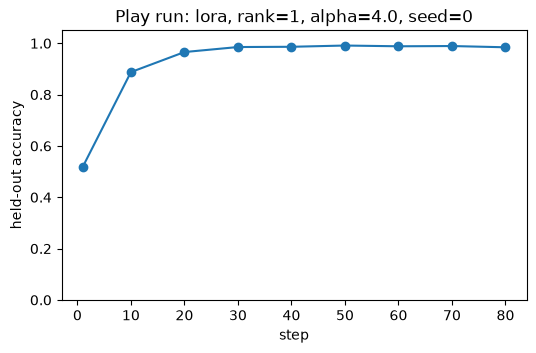

{'id_accuracy': 0.9829, 'ood_accuracy': 0.9863, 'target_direction_cosine': 0.9988, 'protected_abs_cosine': 0.0131, 'singular_values': [21.9656, 0.0]}


In [15]:
PLAY_RANK = 1
PLAY_ALPHA = 4.0
PLAY_SEED = 0
PLAY_METHOD: Literal["lora", "dora", "full"] = "lora"
PLAY_STEPS = 80

play_model, play_trace = train_proxy_adapter(
    method=PLAY_METHOD,
    rank=PLAY_RANK,
    alpha=PLAY_ALPHA,
    seed=PLAY_SEED,
    steps=PLAY_STEPS,
)
play_id = evaluate_proxy_adapter(play_model, seed=7777, batch=2048)
play_ood = evaluate_proxy_adapter(play_model, seed=7778, batch=2048, ood_shift=0.75)

plt.figure(figsize=(6, 3.5))
plt.plot(play_trace["step"], play_trace["eval_accuracy"], marker="o")
plt.ylim(0, 1.05)
plt.xlabel("step")
plt.ylabel("held-out accuracy")
plt.title(f"Play run: {PLAY_METHOD}, rank={PLAY_RANK}, alpha={PLAY_ALPHA}, seed={PLAY_SEED}")
plt.show()

print({
    "id_accuracy": round(play_id["accuracy"], 4),
    "ood_accuracy": round(play_ood["accuracy"], 4),
    "target_direction_cosine": round(play_id["target_direction_cosine"], 4),
    "protected_abs_cosine": round(play_id["protected_abs_cosine"], 4),
    "singular_values": [round(value, 4) for value in play_id["singular_values"]],
})

## Bonus Anomaly Hunt

Find one setting where the behavior metric looks good but the mechanism audit becomes suspicious. Examples to try:

1. Train with too few steps and inspect whether accuracy rises before target-direction cosine stabilizes.
2. Raise the rank and search seeds for a second non-negligible singular value.
3. Increase the OOD conflict shift and find when the frozen distractor still leaks into predictions.
4. Look for a seed where `protected_abs_cosine` or `activation_protected_abs_corr` exceeds the threshold.

A good anomaly writeup should include the changed setting, the failed metric, the plot or table row that revealed it, and a hypothesis for why it happened.

## CUDA Verification Hook

The parent task owns GPU serialization. This notebook keeps the CUDA path visible, but do not run it in this subtask. The parent GPU step should run:

```python
run_full_experiment(max_vram_gb=24.0)
```

The committed report should still be treated as supporting evidence, not as the learner-facing result.

In [16]:
verification_report_path = section_dir / "verification_report.json"
committed_evidence = json.loads(verification_report_path.read_text())
assert committed_evidence["notebook_id"] == EXERCISE_ID, (
    "The committed evidence should belong to this PEFT exercise."
)

def lora_smoke_test() -> dict:
    lora_a = t.tensor([[1.0, 2.0]])
    lora_b = t.tensor([[3.0], [4.0]])
    delta = lora_delta(lora_a, lora_b, alpha=2.0)
    return {
        "delta": delta.tolist(),
        "report": adapter_delta_report(lora_a, lora_b, alpha=2.0).__dict__,
    }


def dora_smoke_test() -> dict:
    base_weight = t.tensor([[3.0, 4.0], [0.0, 2.0]])
    adapter_delta = t.zeros_like(base_weight)
    magnitude = t.tensor([10.0, 5.0])
    report = dora_weight_report(base_weight, adapter_delta, magnitude)
    return {
        "row_norms": [round(value, 6) for value in report.row_norms.tolist()],
        "max_norm_error": report.max_norm_error,
        "norm_preserved": report.norm_preserved,
    }


def intruder_smoke_test() -> dict:
    adapter_delta = t.tensor([[1.0, 0.0], [1.0, 0.0]])
    protected_direction = t.tensor([1.0, 0.0])
    return intruder_dimension_report(
        adapter_delta,
        protected_direction,
        max_projection_fraction=0.5,
    ).__dict__


def mechanism_smoke_test() -> dict:
    return adapter_mechanism_report(
        adapter_accuracy=0.9,
        baseline_accuracy=0.7,
        adapter_mechanism_score=0.8,
        baseline_mechanism_score=0.75,
        min_accuracy_gain=0.1,
        min_mechanism_delta=-0.02,
    ).__dict__


def run_smoke_test(cpu: bool = True) -> dict:
    _ = cpu
    return {
        "lora": lora_smoke_test(),
        "dora": dora_smoke_test(),
        "intruder": intruder_smoke_test(),
        "mechanism": mechanism_smoke_test(),
    }


def run_gpu_test(max_vram_gb: float = 24.0) -> dict:
    return reference.run_gpu_test(max_vram_gb=max_vram_gb)


def run_full_experiment(max_vram_gb: float = 24.0) -> dict:
    return reference.run_full_experiment(max_vram_gb=max_vram_gb)


tests.test_smoke_wrappers_match_the_visible_contract(
    lora_smoke_test,
    dora_smoke_test,
    intruder_smoke_test,
    mechanism_smoke_test,
)
tests.test_notebook_contract(run_smoke_test)
tests.test_committed_verification_report_trained_peft_controls()

All tests in `test_smoke_wrappers_match_the_visible_contract` passed!
All tests in `test_notebook_contract` passed!
All tests in `test_committed_verification_report_trained_peft_controls` passed!


## Limitations and Claim Scope

This notebook supports a narrow safe-proxy claim: on a generated planted-direction classifier, exact LoRA/DoRA math plus matched training and controls can distinguish a learned target mechanism from random-label and same-norm random-adapter failures.

It does not claim that these metrics certify arbitrary public adapters, detect every misalignment failure, or replace real model-specific activation analysis. For a real transformer adapter, you would repeat the same pattern with actual prompts, held-out examples, layer-local activations, task-specific protected directions, and causal interventions.

## Reading Links

- LoRA: Hu et al., 2021, Low-Rank Adaptation of Large Language Models.
- DoRA: Liu et al., 2024, Weight-Decomposed Low-Rank Adaptation.
- Earlier ARENA connection: function vectors and linear probes both use the same pattern of implement, test, intervene, and inspect controls.